In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
idf = pd.read_csv('./reddit-sentiment.csv')  # input df
sdf = pd.read_csv('../arishko2-yahoo/data/HistoricalData_1743103651771.csv')  # yahoo S&P500 data

In [8]:
# Convert 'Date' column to datetime format
sdf['Date'] = pd.to_datetime(sdf['Date'])
sdf_2024 = sdf[sdf['Date'].dt.year == 2024]
sdf_2024 = sdf_2024.sort_values(by=['Date'])
sdf_2024 = sdf_2024.reset_index(drop=True)

sdf_2024 = sdf_2024[['Date', 'Close/Last']]
sdf_2024

,Date,Close/Last
0,2024-01-02,4742.83
1,2024-01-03,4704.81
2,2024-01-04,4688.68
3,2024-01-05,4697.24
4,2024-01-08,4763.54
...,...,...
247,2024-12-24,6040.04
248,2024-12-26,6037.59
249,2024-12-27,5970.84
250,2024-12-30,5906.94


In [27]:
start_price = sdf_2024.iloc[0]['Close/Last']
end_price = sdf_2024.iloc[-1]['Close/Last']
baseline_slope = (start_price - end_price) / len(sdf_2024)

sdf_2024['Baseline'] = start_price - (baseline_slope * sdf_2024.index)
sdf_2024['Deviation'] = sdf_2024['Close/Last'] - sdf_2024['Baseline']


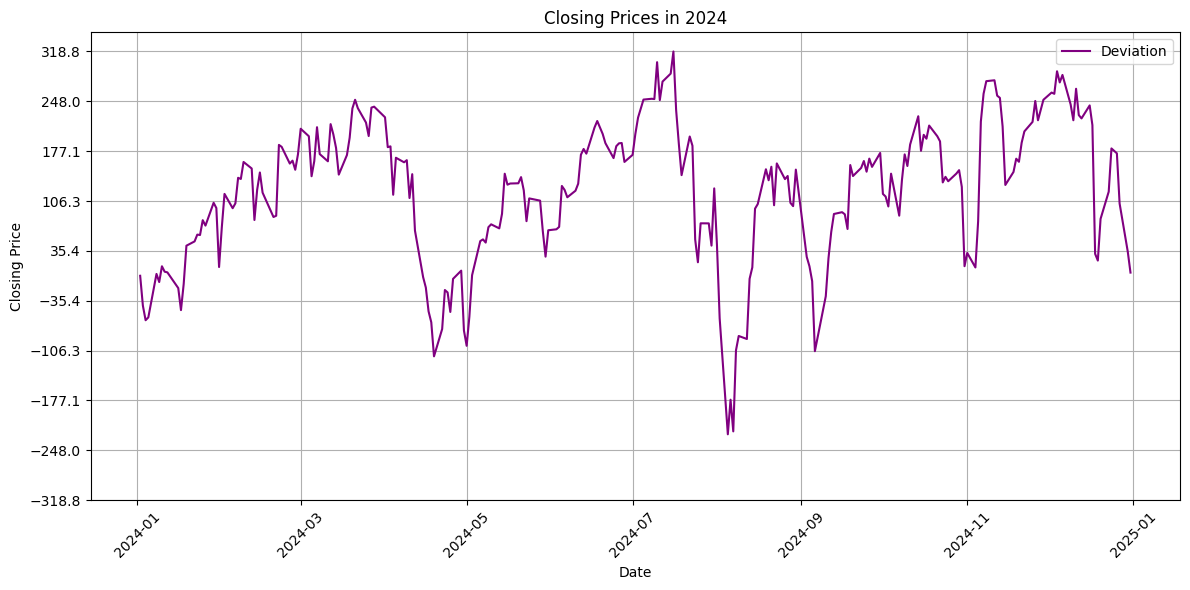

In [ ]:
plt.figure(figsize=(12, 6))
# plt.plot(sdf_2024['Date'], sdf_2024['Close/Last'], linestyle=':', color='b', label='Close/Last')
# plt.plot(sdf_2024['Date'], sdf_2024['Baseline'], linestyle='--', color='orange', label='Baseline')
plt.plot(sdf_2024['Date'], sdf_2024['Deviation'], linestyle='-', color='purple', label='Deviation')

plt.title('Closing Prices in 2024')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.xticks(rotation=45)
plt.yticks(ticks=np.linspace(-max(abs(sdf_2024['Deviation'])), max(abs(sdf_2024['Deviation'])), num=10))
plt.legend()  # Add legend to distinguish the plots
plt.tight_layout()
plt.show()